<a href="https://colab.research.google.com/github/fellAR-hub/Probabilidad/blob/main/unidad5/proyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Probabilidad y estadisticas
#unidad 5
##Practica final
###Facilitador:Jose Gabriel Rodriguez rivas
###Alumno:Abrego Reyes Angel Felipe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

grupo1 = pd.read_csv("grupo1.csv")
grupo2 = pd.read_csv("grupo2.csv")
grupo3 = pd.read_csv("grupo3.csv")

print("Grupo 1:", grupo1.head())
print("Grupo 2:",grupo2.head())
print("Grupo 3:",grupo3.head())

Grupo 1:    HorasEstudio  Calificacion
0         20.00         75.94
1         15.60         87.48
2         17.91         79.40
3         20.00         73.37
4         20.00         83.75
Grupo 2:    HorasEstudio  Calificacion
0          3.79          40.0
1          6.08          26.1
2          7.17          29.0
3          7.54          31.9
4          8.18          34.8
Grupo 3:    HorasEstudio  Calificacion
0          3.79          15.0
1          6.08          26.1
2          7.17          29.0
3          7.54          31.9
4          8.18          34.8


In [ ]:
for i, grupo in enumerate([grupo1, grupo2, grupo3], 1):
    print(f"\n========== GRUPO {i} ==========")
    print(grupo.describe())


========== GRUPO 1 ==========
       HorasEstudio  Calificacion
count     50.000000      50.00000
mean      14.352000      83.78820
std        4.219174       7.83389
min        3.790000      68.46000
25%       12.032500      78.03500
50%       14.600000      84.49000
75%       17.715000      88.09000
max       20.000000     100.00000

========== GRUPO 2 ==========
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.912000
std        4.219174     20.668922
min        3.790000     26.100000
25%       12.032500     63.500000
50%       14.600000     78.550000
75%       17.715000     93.300000
max       20.000000     99.000000

========== GRUPO 3 ==========
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.968000
std        4.219174     23.668867
min        3.790000     15.000000
25%       12.032500     61.000000
50%       14.600000     84.950000
75%       17.715000     94.375000
max       20.000000    

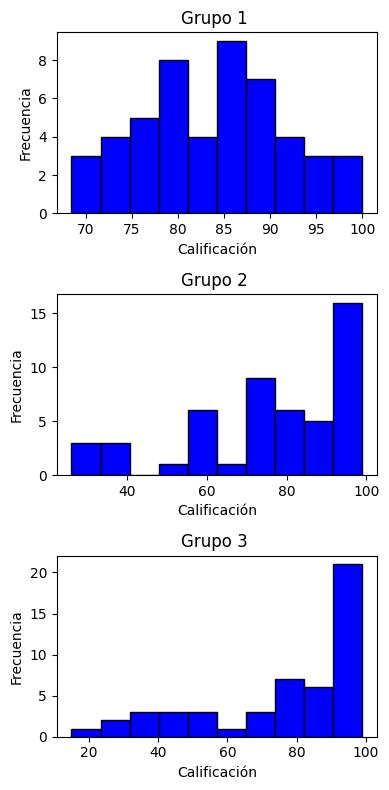

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(4, 8))

for i, (grupo, ax) in enumerate(zip([grupo1, grupo2, grupo3], axes), 1):
    ax.hist(grupo["Calificacion"], bins=10, color="blue", edgecolor="black")
    ax.set_title(f"Grupo {i} ")
    ax.set_xlabel("Calificación")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [ ]:
for i, grupo in enumerate([grupo1, grupo2, grupo3], 1):
    x = grupo["HorasEstudio"].values.reshape(-1, 1)
    y = grupo["Calificacion"].values

    modelo = LinearRegression()
    modelo.fit(x, y)

    pendiente   = modelo.coef_[0]
    intercepto  = modelo.intercept_
    r, p_valor  = stats.pearsonr(grupo["HorasEstudio"], grupo["Calificacion"])

    print(f"\n========== GRUPO {i} ==========")
    print(f"Ecuación: Calificación = {pendiente:.4f} * HorasEstudio + {intercepto:.4f}")
    print(f"Correlación de Pearson (r): {r:.4f}")
    print(f"P-valor: {p_valor:.4f}")
    print(f"R² (coef. determinación): {r**2:.4f}")


========== GRUPO 1 ==========
Ecuación: Calificación = -0.1061 * HorasEstudio + 85.3107
Correlación de Pearson (r): -0.0571
P-valor: 0.6935
R² (coef. determinación): 0.0033

========== GRUPO 2 ==========
Ecuación: Calificación = 4.2227 * HorasEstudio + 15.3075
Correlación de Pearson (r): 0.8620
P-valor: 0.0000
R² (coef. determinación): 0.7430

========== GRUPO 3 ==========
Ecuación: Calificación = 5.2857 * HorasEstudio + 0.1081
Correlación de Pearson (r): 0.9422
P-valor: 0.0000
R² (coef. determinación): 0.8878


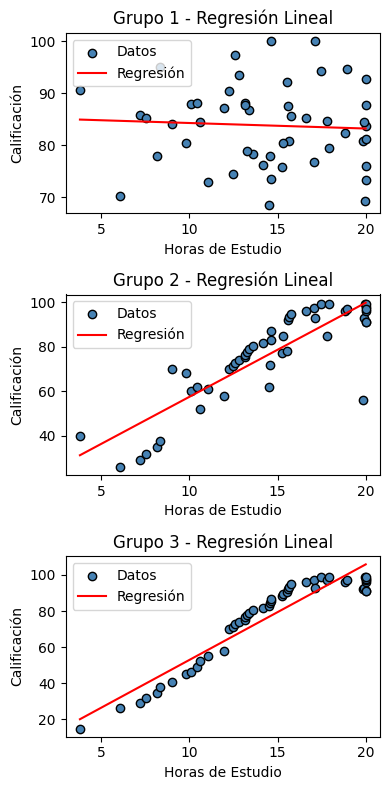

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(4, 8))

for i, (grupo, ax) in enumerate(zip([1, df2, df3], axes), 1):
    x = df["HorasEstudio"].values.reshape(-1, 1)
    y = df["Calificacion"].values

    modelo = LinearRegression()
    modelo.fit(x, y)

    x_linea = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_linea = modelo.predict(x_linea)

    ax.scatter(df["HorasEstudio"], df["Calificacion"],
               color="steelblue", edgecolor="black", label="Datos")
    ax.plot(x_linea, y_linea, color="red", label="Regresión")
    ax.set_title(f"Grupo {i} - Regresión Lineal")
    ax.set_xlabel("Horas de Estudio")
    ax.set_ylabel("Calificación")
    ax.legend()

plt.tight_layout()
plt.show()

#**Preguntas**
###1-**Explicacion de cuál es la interpretación del coeficiente de regresión en términos de la relación entre el tiempo de estudio y las calificaciones finales:**
#####Grupo1: La pendiente es -0.10, osea que por cada hora extra de estudio la calificación baja 0.10 puntos. Sin embargo este valor no tiene efecto real al ser muy cercano a 0.

#####Grupo2:La pendiente es 4.22, lo que significa que por cada hora adicional de estudio la calificación sube aproximadamente 4.22 puntos

#####Grupo3:La pendiente es 5.28, lo que significa que por cada hora adicional de estudio la calificación sube aproximadamente 5.28 puntos,siendo la relacion mas fuerte de los 3 grupos


###2. **¿Cómo se interpreta el coeficiente de correlación en términos de la fuerza y dirección de la relación entre las variables?**

#####Grupo1: este nos dice que no existe relación entre horas de estudio y calificaciones en este grupo. La dirección negativa es irrelevante dado lo débil que es.

#####Grupo2:r = 0.8620 indica una correlación positiva fuerte, o sea que a más horas de estudio, mayor calificación, siento una relacion bastante consistente

#####Grupo3:r= 0.9422 indica una correlación positiva muy fuerte. Es la relación más fuerte de los 3 grupos

###3. **¿El modelo de regresión lineal es estadísticamente significativo?**
#####Grupo1:El p-valor es de 0.69, osea que esta muy por encima de 0.05, por lo que el modelo no es estadísticamente significativo.

#####Grupo2: El p-valor es basicamente 0, muy por debajo de 0.05, el modelo es altamente significativo

#####Grupo3:si ya que el P-valor prácticamente 0,al igual que le grupo 2, el modelo es altamente significativo

###**¿Qué tan confiable es el modelo de regresión para predecir las calificaciones finales de los estudiantes basado en el tiempo de estudio?**
#####Grupo1: no es muy confiable ya que el R² = 0.0033 lo que significa que solo el 0.33% de la variación en calificaciones se explica por las horas de estudio.

#####Grupo2:es bastante confiable ya que el R² = 0.7430 significa que el 74.30% de la variación en calificaciones se explica por las horas de estudio.

#####Grupo3:es muy confiable ya que el R² = 0.8878 significa que el 88.78% de la variación en calificaciones se explica por las horas de estudio.









#**CONCLUSIÓN**
##Pudimos apreciar como las horas de estudio afectaban al rendimiento academico y sus calificaciones basandonos en diagramas de relacion y regresion pero no todas siendo confiables.
##Como en el grupo 1 que no habia relacion y practicamente tenia una fiabilidad del 0.33% esto era basicamente falso o nada confiable en comparacion con los otros esquemas que mostraban una fiabilidad de 74% a 89%  y con relaciones mas fuertes que podian explicar la relacion entre las horas de estudio y su calificacion.
##la correlacion nos ayuda a medir que tan relacionadas estan 2 variables y nos ayudan a responder preguntas como si tienen relacion debil , fuerte o siquiera la tienen, que tan confiable es un modelo y a saber si la regresion tiene sentido